[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026-CS1090A-public/blob/sec06-2026/sec06/cs1090a_sec06_student.ipynb)

> **On Colab, do `File → Save a copy in Drive` before you start.** This notebook opens from GitHub, so you can type in it and run it right away — but nothing is being saved anywhere. Close the tab and the work is gone. Saving a copy first gives you one that persists in your own Drive.

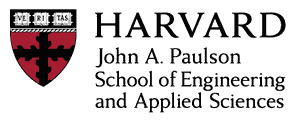

# CS1090A Introduction to Data Science

### Section 6 — Missing Data and Principal Components

In [ ]:
# Provided — setup. On Colab this fetches the data files this notebook needs.
# Everywhere else it does nothing except confirm they are already here.
#
# Generated at publish time; see utils/inject_colab_bootstrap.py. Editing this cell
# in the public repo is wasted work -- the next publish overwrites it.
import os
import shutil
import subprocess
import sys

_REPO    = "https://github.com/Harvard-CS1090/2026-CS1090A-public"
_REF     = "sec06-2026"
_SECTION = "sec06"

_DIRNAME = _REPO.rstrip("/").split("/")[-1].removesuffix(".git")

if os.path.isdir("data"):
    print(f"data/ is present -- nothing to fetch.")
elif "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook reads its inputs from a data/ folder, which is not here.\n"
        "It does not fetch them from the live web -- that is deliberate, and Part 1\n"
        "explains why.\n\n"
        "Fix: get the whole folder, not just the notebook --\n"
        f"    git clone --branch {_REF} {_REPO}\n"
        f"    cd {_DIRNAME}/{_SECTION}\n"
        "    jupyter lab\n\n"
        "Then open this notebook from in there. (On Colab, this cell fetches it for you.)"
    )
else:
    print("Colab detected, no data/ -- fetching it once...")
    _tmp = "/content/_cs1090a_materials"
    if not os.path.isdir(_tmp):
        _r = subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", _REF, _REPO, _tmp],
            capture_output=True, text=True,
        )
        if _r.returncode != 0:
            raise RuntimeError(
                f"Could not download the data files from {_REPO} (ref {_REF}).\n\n"
                f"git said: {_r.stderr.strip().splitlines()[-1] if _r.stderr.strip() else 'no output'}\n\n"
                "This is not something you did wrong. Post on Ed with this message and\n"
                "a TF will sort it out; meanwhile the section notebook will not run here."
            )
    _dir = os.path.join(_tmp, _SECTION)
    _src = os.path.join(_dir, "data")
    if not os.path.isdir(_src):
        raise RuntimeError(
            f"Cloned {_REPO} at {_REF} but found no {_SECTION}/data in it.\n"
            "The published bundle is incomplete -- please report this on Ed."
        )
    shutil.copytree(_src, "data")

    # Sibling modules too, not just data/. Section 1 does `from section_helpers import
    # Recorded`; fetching data/ alone leaves that import failing three cells later,
    # which reads as "the notebook is broken" rather than "setup was incomplete".
    _mods = [f for f in os.listdir(_dir) if f.endswith(".py")]
    for _m in _mods:
        shutil.copy(os.path.join(_dir, _m), _m)

    print(f"data/ ready ({len(os.listdir('data'))} entries)"
          + (f", plus {', '.join(sorted(_mods))}." if _mods else "."))


<div style="background:#E8F1FF; border-left:6px solid #2563EB; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🎯 Objectives — what you should be able to do by the end</div>
<div>
<ul>
<li>Understand the three missing-data mechanisms (missing completely at random (MCAR), missing at random (MAR), and missing not at random (MNAR)) and determine which applies from a description of how values became missing.</li>
<li>Implement complete-case analysis, mean imputation, and regression imputation, and explain how their effects on means, slopes, and variability depend on the missing-data mechanism.</li>
<li>Apply principal component analysis (PCA), interpret the components, and choose how many to retain.</li>
</ul>
</div>
</div>

**Coloured boxes:** 🤔 commit to a prediction before running the code · 🏋️ write code (look for `# your code here`) · 💬 stop running cells and discuss · ⭐ the point of the exercise · 💡 connect it to your own work · 🧠 what to carry out of the room · 🔍 an appendix item to work through on your own afterwards.

**The data.** 342 penguins with complete measurements of three species, measured at Palmer Station in Antarctica: the
length and depth of the bill, the length of the flipper, and the body mass. We first
simulate missing values and compare ways to handle them, then ask how many separate quantities its
four measurements record.

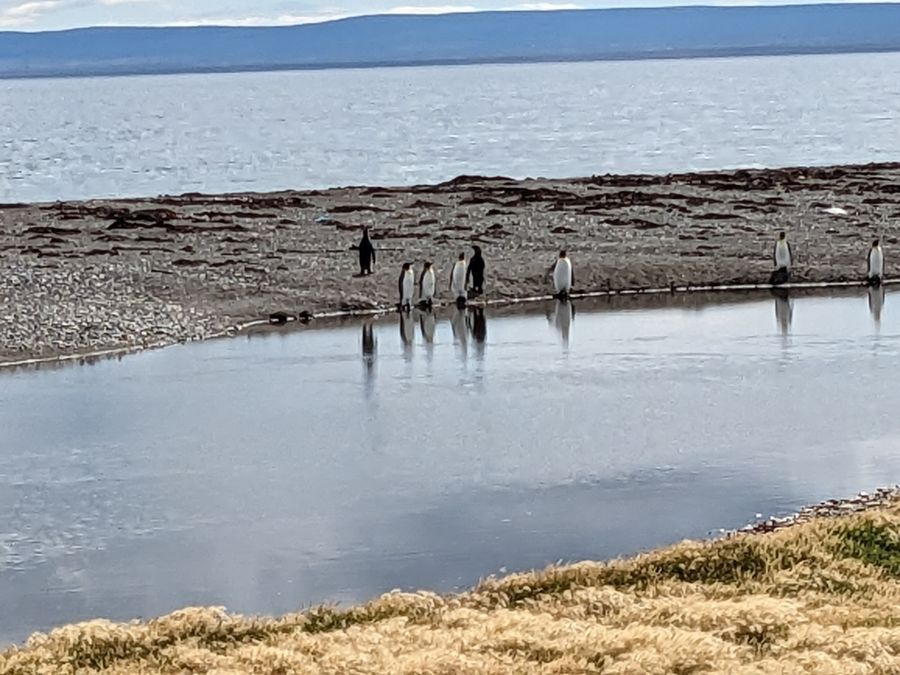


<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — before anything runs</div>
<div>
<ul>
<li>We will delete 30% of the body-mass values completely at random, fill each blank with the mean of the values that remain, and refit the slope of body mass on flipper length. Will the slope come back about the same, larger, or smaller?</li>
<li>We will then run principal component analysis on the four raw measurements: three in millimetres and one in grams. What share of the total variance will the first component carry: about a quarter, about two thirds, or nearly all of it?</li>
</ul>
Write both down. You will come back to them at the end.
</div>
</div>

## Part A. Missingness

### A1. Understanding missingness through simulation

In this part, we deliberately create missing values to understand how MCAR, MAR, and MNAR work. This is a learning exercise: we know the original values and control how they become missing. We start with complete measurements, then simulate each mechanism.

#### Load the data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# New in this section: principal component analysis
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")

In [ ]:
# Load the complete measurements used in this section.
measurements = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
df = (
    pd.read_csv("data/penguins.csv", usecols=["species", *measurements])
    .dropna(subset=measurements)
    .reset_index(drop=True)
)
print(f"{len(df)} penguins with all four measurements")


In [ ]:
# Confirm that our starting dataset has no missing values.
df.isna().sum()

#### Three ways a value can go missing

As discussed in lecture, there are three missing-data mechanisms, describing how values become missing.

- A value is **missing completely at random (MCAR)** when every row had the same chance of
  losing it, whatever else is true of that row. For example, a scale that failed on a
  random 30% of days.
- A value is **missing at random (MAR)** when the chance of losing it depends only on
  columns that were recorded. For example, penguins with long flippers, which are large
  and hard to hold, were weighed less often.
- A value is **missing not at random (MNAR)** when the chance of losing it depends on the
  missing value itself, or on something that was never recorded. For example, a scale
  that could not register the heaviest penguins.

Under MAR the blanks are still concentrated in one kind of penguin: "at random" means
random once you account for the recorded columns.

> **A note on the names:** These names can be confusing, so don’t worry if they feel unintuitive at first. In everyday language, “missing at random” sounds like values disappear entirely by chance, which is what MCAR describes. MAR allows missingness to depend on recorded variables; once those are held constant, it does not depend on the missing value itself. Read the three names together and focus on what causes the missingness, rather than relying on the names alone.


At this point, our dataset has no missing values. To compare the three missing-data
mechanisms, we will make a separate copy for each one and remove about 30% of the
body-mass values, keeping the original values for reference. We can then compare how
well each method for handling missing data recovers the original mean, standard
deviation, and relationship between body mass and flipper length.


#### The truth to measure against

In [ ]:
def slope_of(frame, mass):
    # Slope of body mass on flipper length.
    return LinearRegression().fit(frame[["flipper_length_mm"]], mass).coef_[0]

truth = {
    "mean": df["body_mass_g"].mean(),
    "sd": df["body_mass_g"].std(ddof=1),
    "slope": slope_of(df, df["body_mass_g"]),
}
pd.Series(truth).rename(index={
    "mean": "mass mean", "sd": "mass sd", "slope": "slope mass vs flipper length"
}).round(1)


#### Rules for losing a value

Each rule gives every penguin a probability of losing its body mass.

In [ ]:
# MCAR: every penguin has the same 30% chance
p_mcar = pd.Series(0.30, index=df.index)

p_mcar

#### MNAR: missingness depends on body mass

For MNAR, we make heavier penguins more likely to have their body mass missing. We use the complete masses to set these probabilities before hiding any values.

The plot shows the probability of hiding a mass at each body mass. It defines the rule; no values have been removed yet.


In [ ]:
def probability_of_missingness_from_mass(mass):
    # Express mass in standard-deviation units.
    standardized_mass = (mass - mass.mean()) / mass.std(ddof=1)
    # Convert to a probability: heavier penguins are more likely to have missing mass.
    return 1 / (1 + np.exp(-(standardized_mass - 1)))


In [ ]:
# MNAR: the chance rises with body mass itself, the value that goes missing
p_mnar = probability_of_missingness_from_mass(df["body_mass_g"])

# Sort masses so the line follows increasing body mass.
order = np.argsort(df["body_mass_g"].to_numpy())
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(df["body_mass_g"].to_numpy()[order], p_mnar.to_numpy()[order])
ax.set(
    xlabel="Body mass (g)",
    ylabel="Probability of body mass being missing",
    title="MNAR: missingness depends on mass",
    ylim=(0, 1),
)
ax.set_facecolor("white")
ax.grid(True, color="#dddddd", linewidth=0.6)
ax.tick_params(labelsize=9)
ax.xaxis.label.set_size(10)
ax.yaxis.label.set_size(10)
ax.title.set_fontsize(10)
fig.tight_layout()
plt.show()


<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 1: write the MAR rule (4 min)</div>
<div>
For MAR, the probability of a missing body mass must depend only on variables that remain recorded. Here, use flipper length: penguins with longer flippers should be more likely to have missing mass.
<br><br>
Adapt <code>probability_of_missingness_from_mass</code> to create a function named <code>probability_of_missingness_from_flipper_length</code>. Use it to calculate <code>p_mar</code>, then plot the probability of missing body mass against flipper length.
</div>
</div>

In [ ]:
# your code here
def probability_of_missingness_from_flipper_length(flipper_length):
    ...
p_mar = ...
Plot the probability against flipper length.


#### Blanking body mass three times

In [ ]:
def blank_out(frame, probability):
    # Copy the frame and set body_mass_g to NaN in each row with the given probability
    out = frame.copy()
    # Cast to float first: pandas 3 refuses to write NaN or a non-integer value into an integer column
    out["body_mass_g"] = out["body_mass_g"].astype(float)
    lost = rng.random(len(out)) < probability.to_numpy()
    out.loc[lost, "body_mass_g"] = np.nan
    return out

In [ ]:
# Set a fixed random seed so rerunning this cell hides the same body-mass values.
rng = np.random.default_rng(109)
masked = {
    "MCAR": blank_out(df, p_mcar),
    "MAR": blank_out(df, p_mar),
    "MNAR": blank_out(df, p_mnar),
}
# All rows remain; only some body-mass values are hidden.
pd.DataFrame({
    "Total penguins": {name: len(frame) for name, frame in masked.items()},
    "Missing body mass": {name: int(frame["body_mass_g"].isna().sum()) for name, frame in masked.items()},
    "Recorded body mass": {name: int(frame["body_mass_g"].notna().sum()) for name, frame in masked.items()},
}).rename_axis("Mechanism")

<hr>
<hr>
<hr>
<hr>

### A2. Analyzing data with missing values

In practice, you usually receive data with missing values already present. The steps above generated missingness so you could understand how MCAR, MAR, and MNAR work.

From this point on, imagine that these incomplete datasets are the data you have been given. We will first examine the missingness patterns, then compare ways to handle the missing values. We keep the original complete data only as a reference for evaluating our methods in this exercise; in practice, those missing values would usually be unknown.


#### Missing rate against flipper length

We want to see whether body mass is missing more often for penguins with longer flippers.
To visualize this, we divide the recorded flipper lengths into six ranges, called bins
(or bands), each containing about the same number of penguins. The ranges can have different widths.

For each missing-data mechanism, we calculate the fraction of penguins in each bin whose
body mass is missing: the number with missing mass divided by the total number in that bin.
For example, if 15 of 50 penguins in a bin have missing mass, its missing rate is 30%.
We include penguins with and without a recorded mass; their flipper lengths remain available.

Each point shows a bin's missing rate at the midpoint of its flipper-length range.
The three panels use the same bins, so we can compare the patterns across mechanisms.


<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — which panel is flat?</div>
<div>
Predict the patterns before running the plots.
<ol>
<li>Which of the three panels do you expect to be approximately flat?</li>
<li>Will you be able to tell the MAR panel from the MNAR panel?</li>
</ol>
Commit to both before running the cell.
</div>
</div>

In [ ]:
# Missing rate against flipper length, one panel per mechanism
flipper_band = pd.qcut(df["flipper_length_mm"], 6, duplicates="drop")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, constrained_layout=True)
for ax, (mechanism, frame) in zip(axes, masked.items()):
    by_band = frame["body_mass_g"].isna().groupby(flipper_band, observed=True).mean()
    centres = [interval.mid for interval in by_band.index]
    ax.plot(centres, by_band.values, marker="o", linewidth=2, color="#DC2626")
    ax.axhline(frame["body_mass_g"].isna().mean(), color="#4B5563", linestyle=":", linewidth=1)
    ax.set(title=mechanism, xlabel="flipper_length_mm (centre of band)", ylim=(0, 0.8))
axes[0].set_ylabel("share of body_mass_g missing")
fig.suptitle("How often body mass is missing, by flipper length (dotted: overall rate)")
plt.show()


print("correlation of flipper length and body mass (complete data):",
      round(df["flipper_length_mm"].corr(df["body_mass_g"]), 2))


The MAR and MNAR panels both rise. The table below summarizes what we can calculate about these two frames from the recorded values alone.

Here, complete cases are penguins with a recorded body mass. The slope comes from regressing body mass on flipper length using those penguins, and is measured in grams per millimetre.


In [ ]:
def observed_summary(frame):
    # Statistics you could compute without the missing values
    missing = frame["body_mass_g"].isna()
    return {
        "share of masses missing": missing.mean(),
        "complete-case mean mass (g)": frame.loc[~missing, "body_mass_g"].mean(),
        "complete-case slope: mass on flipper length (g/mm)": slope_of(frame[~missing], frame.loc[~missing, "body_mass_g"]),
        "mean flipper length, rows with a mass (mm)": frame.loc[~missing, "flipper_length_mm"].mean(),
        "mean flipper length, rows without (mm)": frame.loc[missing, "flipper_length_mm"].mean(),
    }

pd.DataFrame({mechanism: observed_summary(masked[mechanism]) for mechanism in ["MAR", "MNAR"]}).round(2)

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 1: telling MAR from MNAR</div>
<div>
<p>Imagine you were given these incomplete data without knowing how the missing values were generated.</p>
<ol>
<li>Which panel is most consistent with MCAR? Does a roughly flat pattern prove that missingness is completely random?</li>
<li>Could the increasing missing-rate pattern alone tell you whether the mechanism is MAR or MNAR?</li>
<li>What would you need to know about how the measurements were collected?</li>
</ol>
</div>
</div>


<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — what a missing-rate plot can and cannot tell you</div>
<div>
A systematic association between missingness and a recorded variable is evidence against MCAR. It does not, by itself, distinguish MAR from MNAR. Both mechanisms can produce similar patterns, so interpreting missingness requires assumptions about how the data were collected.
</div>
</div>

### A3. Comparing methods for handling missing values

We now compare three ways to handle the missing body-mass values: complete-case analysis, mean imputation, and regression imputation. We start with the MCAR dataset, then apply the same methods to the MAR and MNAR datasets.


#### Complete-case analysis

**Complete-case analysis** uses only penguins whose body mass is recorded. For the MCAR dataset, this leaves 238 of the 342 penguins. We estimate the mean body mass and the slope of body mass on flipper length using those 238 penguins, then compare them with the complete-data reference.

Remember: we are now analyzing the incomplete data as if they had been given to us. The earlier preparation steps were there to demonstrate how missingness arises.


In [ ]:
# The MCAR frame, which rows lost their body mass, and the complete cases
frame = masked["MCAR"]
missing = frame["body_mass_g"].isna()
observed = frame[~missing]

# Mean and SD describe body masses; slope is body mass on flipper length.
print("Complete-case analysis: observed penguins only")
print("Statistic                            Estimate   Reference")
print(f"Mean body mass (g)                    {observed['body_mass_g'].mean():8.1f}    {truth['mean']:8.1f}")
print(f"SD of body mass (g)                   {observed['body_mass_g'].std(ddof=1):8.1f}    {truth['sd']:8.1f}")
print(f"Slope: mass on flipper length (g/mm)   {slope_of(observed, observed['body_mass_g']):8.1f}    {truth['slope']:8.1f}")


#### What do we learn from complete-case analysis?

Under **MCAR**, keeping only penguins with a recorded mass is a reasonable approach. Here, the estimated mean and slope remain close to the complete-data reference. They need not match exactly: removing observations introduces sampling variation, but MCAR does not systematically select penguins by their measurements.

The cost is fewer observations and generally less precise estimates. We do not have to impute simply because values are missing. In this example, filling the missing masses does not create new measured outcomes; simple imputation can even distort the slope or variability. Next, we compare imputation methods to see what they change and whether they help.


#### Mean imputation

To **impute** a value is to fill a blank with a computed one. **Mean imputation** fills
every blank with the mean of the observed values.

In [ ]:
# Fill every blank with the mean of the observed masses; the imputed rows are shown
mean_filled = frame["body_mass_g"].fillna(observed["body_mass_g"].mean())
mean_filled[missing].head()

In [ ]:
# Mean and SD describe body masses; slope is body mass on flipper length.
print("Mean imputation: observed and imputed penguins")
print("Statistic                            Estimate   Reference")
print(f"Mean body mass (g)                    {mean_filled.mean():8.1f}    {truth['mean']:8.1f}")
print(f"SD of body mass (g)                   {mean_filled.std(ddof=1):8.1f}    {truth['sd']:8.1f}")
print(f"Slope: mass on flipper length (g/mm)   {slope_of(frame, mean_filled):8.1f}    {truth['slope']:8.1f}")


#### Regression imputation

**Regression imputation** fits a regression of the missing column on a recorded column,
using only the rows where both are present, and fills each blank with that model's
prediction. Here the regression is body mass on flipper length.

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 2: regression imputation (4 min)</div>
<div>
Complete <code style="background:rgba(0,0,0,0.06); color:#1F2937;">regression_impute</code>. Fit <code style="background:rgba(0,0,0,0.06); color:#1F2937;">imputer</code>, a <code style="background:rgba(0,0,0,0.06); color:#1F2937;">LinearRegression</code> of body mass on flipper
length, on the <code style="background:rgba(0,0,0,0.06); color:#1F2937;">observed</code> rows only. Then fill the blanks in <code style="background:rgba(0,0,0,0.06); color:#1F2937;">filled</code> with its predictions
for the flipper lengths of the rows in <code style="background:rgba(0,0,0,0.06); color:#1F2937;">missing</code>. The first two lines inside the function
are the same steps as above.
</div>
</div>

In [ ]:
def regression_impute(frame):
    # Fill body_mass_g's blanks with predictions from flipper length, fitted on the observed rows
    missing = frame["body_mass_g"].isna()
    observed = frame[~missing]
    # your code here
    imputer = LinearRegression().fit(..., ...)  # mass on flipper length, observed rows only
    filled = frame["body_mass_g"].copy()
    filled[missing] = imputer.predict(...)     # the flipper lengths of the rows with a blank
    return filled

In [ ]:
regression_filled = regression_impute(frame)

# Mean and SD describe body masses; slope is body mass on flipper length.
print("Regression imputation: observed and imputed penguins")
print("Statistic                            Estimate   Reference")
print(f"Mean body mass (g)                    {regression_filled.mean():8.1f}    {truth['mean']:8.1f}")
print(f"SD of body mass (g)                   {regression_filled.std(ddof=1):8.1f}    {truth['sd']:8.1f}")
print(f"Slope: mass on flipper length (g/mm)   {slope_of(frame, regression_filled):8.1f}    {truth['slope']:8.1f}")


#### MCAR: compare the three methods

The table below compares complete-case analysis, mean imputation, and regression imputation for the MCAR dataset. The first row shows the complete-data reference; each following row shows one method. The three columns report mean body mass, standard deviation of body mass, and the slope of body mass on flipper length. Here, standard deviation describes the spread of body masses, not uncertainty in the estimated mean or slope.


In [ ]:
def compare_methods(dataset):
    # The same three statistics for each method, plus the complete-data reference.
    recorded = dataset.dropna(subset=["body_mass_g"])
    mean_imputed = dataset["body_mass_g"].fillna(recorded["body_mass_g"].mean())
    regression_imputed = regression_impute(dataset)

    def summarize(rows, mass):
        return [mass.mean(), mass.std(ddof=1), slope_of(rows, mass)]

    return pd.DataFrame.from_dict({
        "Complete-data reference": [truth["mean"], truth["sd"], truth["slope"]],
        "Complete-case analysis": summarize(recorded, recorded["body_mass_g"]),
        "Mean imputation": summarize(dataset, mean_imputed),
        "Regression imputation": summarize(dataset, regression_imputed),
    }, orient="index", columns=[
        "Mean mass (g)", "SD of mass (g)", "Slope: mass on flipper length (g/mm)"
    ]).rename_axis("Method")

mcar_results = compare_methods(masked["MCAR"])
mcar_results.round(1)


<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 2: what changes under MCAR?</div>
<ol><li>How close are the complete-case mean, SD, and slope to the reference?</li><li>Why does mean imputation preserve the observed mean but reduce the SD and slope? Sketch where the filled-in points appear before running the plot below.</li><li>What changes under regression imputation? Does it improve the slope over complete-case analysis?</li></ol>
</div>


In [ ]:
# The MCAR frame after each imputation: observed and imputed points, the true line, the refitted line
grid = pd.DataFrame({"flipper_length_mm": np.linspace(170, 235, 50)})
true_line = LinearRegression().fit(df[["flipper_length_mm"]], df["body_mass_g"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)
for ax, filled, label in [(axes[0], mean_filled, "mean imputation"),
                          (axes[1], regression_filled, "regression imputation")]:
    refit = LinearRegression().fit(frame[["flipper_length_mm"]], filled)
    ax.scatter(observed["flipper_length_mm"], observed["body_mass_g"], s=14, alpha=0.35,
               color="#2563EB", label=f"observed ({len(observed)})")
    ax.scatter(frame.loc[missing, "flipper_length_mm"], filled[missing], s=18, alpha=0.85,
               color="#DC2626", label=f"imputed ({int(missing.sum())})")
    ax.plot(grid, true_line.predict(grid), color="#4B5563", linestyle="--",
            label=f"true slope {truth['slope']:.1f} g/mm")
    ax.plot(grid, refit.predict(grid), color="#DC2626", linewidth=2,
            label=f"refitted slope {refit.coef_[0]:.1f} g/mm")
    ax.set(title=f"MCAR frame, {label}", xlabel="flipper_length_mm")
    ax.legend(loc="upper left")
axes[0].set_ylabel("body_mass_g")
plt.show()

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — what each imputation puts on the scatter plot</div>
<div>
<p>Mean imputation puts every imputed penguin at the same height, so the left-hand panel
has a horizontal row of red points, and a least-squares line has to pass close to them,
which pulls it toward horizontal. The same row adds nothing to the spread, so the standard
deviation shrinks too. Mean imputation can distort the slope and variance even when missingness is MCAR. MCAR makes complete-case analysis reasonable here; it does not make every imputation method valid.</p>
<p>Regression imputation puts every imputed penguin exactly on the fitted line, so the
refitted slope is the imputation model's own slope, which was fitted on the observed rows:
it is the complete-case slope, no better and no worse. What imputation buys is keeping the
rows, for example for their other columns. Its standard deviation is still too small,
because real penguins scatter around the line and imputed ones do not. Extension E1 adds
that scatter back.</p>
</div>
</div>

#### MAR and MNAR: compare the same methods

Now repeat the comparison for the other two datasets. The rows are grouped by missing-data mechanism, with the same three methods and the complete-data reference in each group.


In [ ]:
results = pd.concat(
    {name: compare_methods(masked[name]) for name in ["MAR", "MNAR"]},
    names=["Mechanism", "Method"],
)
results.round(1)


<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 3: what changes under MAR and MNAR?</div>
<ol><li>Compare the complete-case means with the reference. Which penguins are more likely to have missing mass under these mechanisms?</li><li>Under MAR, the complete-case slope stays close to the reference here. Why can the mean change more than the slope?</li><li>Does regression imputation fix the complete-case slope under MNAR? What happens to the SD under each imputation method?</li></ol>
</div>


## Part B. Principal component analysis (PCA)

### B1. Introduction to PCA

For PCA, we return to the 342 penguins with complete measurements, before we introduced missingness. Section A3 showed that imputation changes a column’s variance. Optional extension E3 explores how those changes affect PCA.

**Principal component analysis (PCA)** builds new columns, called **principal components**,
from a table of numeric columns. Each component is a weighted sum of the original columns.
The first component (PC1) is the weighted sum with the largest possible variance, the second
(PC2) has the largest variance among weighted sums uncorrelated with PC1, and so on. The
weights are the **loadings**, and each component's share of the total variance is its
**explained variance ratio**. 

**PCA does not use the prediction target, so applying PCA does not guarantee better predictive performance.** It finds directions with high variance in the input variables, not directions that best predict the target. Keeping only some components can discard information that matters for prediction.

**Return to the second question in “Predict — before anything runs” at the beginning of this notebook:** how much of the total variance will the first principal component explain when we use the raw measurements?

 We are about to run PCA on the four measurements exactly
as they are in the file: three lengths in millimetres and one mass in grams. Check what you
wrote at the start, and if you said "nearly all", name the column before running the next
cells.

### B2. Why scaling matters

#### Standard deviation and variance of each raw column

In [ ]:
# Show spread in both the original units and squared units.
X = df[measurements]
spread = pd.DataFrame({
    "Unit": ["mm", "mm", "mm", "g"],
    "Standard deviation": X.std(ddof=1),
    "Variance": X.var(ddof=1),
    "Variance unit": ["mm²", "mm²", "mm²", "g²"],
})
spread.round(1)


Remember: variance is the square of the standard deviation. Standard deviation is in the original measurement units; variance is in squared units. For body mass, an SD of about 802 g corresponds to a variance of about 643,000 g². PCA maximizes variance, which is why we show both.


#### PCA on the raw measurements

In [ ]:
# PCA on the four measurements exactly as they are in the file
raw_pca = PCA().fit(X)
print("PC1's share of the variance:", raw_pca.explained_variance_ratio_[0].round(4))

# PC1's loadings on the raw measurements
pd.Series(raw_pca.components_[0], index=measurements).round(3)

Body mass is measured in grams, so its numbers, and its variance, are far larger than the
other three columns', and the direction of largest variance is the body-mass axis. Measure
mass in kilograms instead and PC1 changes, though no penguin has changed.

#### Standardizing

**Standardizing** each column (subtracting its mean and dividing by its standard deviation)
gives every column variance 1, so the four columns start with equal shares of the total
variance.

In [ ]:
scaler = StandardScaler().fit(X)
X_scaled = pd.DataFrame(scaler.transform(X), columns=measurements)
X_scaled.var(ddof=0).round(3)

### B3. Interpreting principal components

#### PCA on the standardized measurements

In [ ]:
# Share of the total variance carried by each component
pca = PCA().fit(X_scaled)
component_names = [f"PC{i + 1}" for i in range(len(measurements))]
pd.Series(pca.explained_variance_ratio_, index=component_names).round(3)

In [ ]:
# The loadings (the weight each component puts on each measurement)
loadings = pd.DataFrame(pca.components_, columns=measurements, index=component_names)
loading_table = loadings.copy()
loading_table.insert(0, "Explained variance (%)", 100 * pca.explained_variance_ratio_)
loading_table.round(2)

Look at the PC1 row in the loadings table. Bill length, flipper length, and body mass have positive loadings, while bill depth has a negative loading. These are weights, not scores or amounts of variance. For a given penguin, each standardized measurement is multiplied by its weight, and the four contributions are added to obtain its PC1 score. Holding the other measurements fixed, increasing a positively weighted measurement raises the score; increasing bill depth lowers it. The explained-variance column describes the spread of scores across penguins, not whether an individual score goes up or down.

Read the PC1 row: which loading has the opposite sign to the other three? (The overall sign
of a component is arbitrary: flipping every loading in a row gives the same component. Only
the signs *relative to each other* carry meaning.)

#### Correlation between bill depth and body mass: all penguins and within each species

Recall Simpson’s paradox from Section 3: an association can reverse sign when groups are combined. Here we compare the correlation between bill depth and body mass across all penguins together (the pooled correlation) and separately within each species.

The pooled correlation is negative, while each within-species correlation is positive. Species differences explain the reversal: Gentoo penguins tend to be heavier and have shallower bills than the other species, even though heavier penguins within each species tend to have deeper bills.

PCA uses all species together. The positive mass loading and negative bill-depth loading in PC1 are consistent with this pooled pattern. PCA does not create the negative correlation. The correlation helps us interpret the loadings, but does not determine them by itself: PCA considers all four measurements together.


In [ ]:
# Correlation of bill depth with body mass: all penguins pooled, then within each species
pooled = df["bill_depth_mm"].corr(df["body_mass_g"])
within = {species: group["bill_depth_mm"].corr(group["body_mass_g"])
          for species, group in df.groupby("species")}
pd.Series({"pooled": pooled, **within}).round(2)

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 4: reading PC1 and PC2</div>
<div>
<ul>
<li>PC1's loading on bill depth has the opposite sign to its loadings on the other three measurements. Which of the correlations above does that match: the pooled one or the within-species ones?</li>
<li>PC2 puts almost all its weight on the two bill measurements, with the same sign. Describe in words a penguin with a high PC2 score.</li>
<li>PCA was never given the <code style="background:rgba(0,0,0,0.06); color:#1F2937;">species</code> column. Is the opposite sign on bill depth a fact about penguins, or a fact about this table?</li>
</ul>
</div>
</div>

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — what PC1 and PC2 measure here</div>
<div>
Read the loadings as weights in a sum of standardized measurements. In PC1, bill length, flipper length, and body mass enter with positive weights; bill depth enters with a negative weight. PC2 mainly weights the two bill measurements. Read the explained-variance column separately: it tells us how much of the total variance each component captures.
</div>
</div>

### B4. How many components to keep

A **scree plot** shows each component's explained variance ratio in order, with the running
total alongside. A common convention is to keep the smallest number of components whose
running total reaches a chosen share of the variance; here we use 85%. A penguin's
**scores** are its coordinates on the components, and `pca.transform` computes them.

#### The scree plot

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 3: the running total and the component scores (3 min)</div>
<div>
Two blanks. In the first cell, compute <code style="background:rgba(0,0,0,0.06); color:#1F2937;">cumulative</code>, the running total of <code style="background:rgba(0,0,0,0.06); color:#1F2937;">ratio</code>
(<code style="background:rgba(0,0,0,0.06); color:#1F2937;">np.cumsum</code> gives the running total of an array). In the cell under "Component scores",
compute <code style="background:rgba(0,0,0,0.06); color:#1F2937;">scores</code> with <code style="background:rgba(0,0,0,0.06); color:#1F2937;">pca.transform(X_scaled)</code>, which returns one row per penguin and one
column per component.
</div>
</div>

In [ ]:
ratio = pca.explained_variance_ratio_

# your code here
cumulative = ...  # the running total of ratio

# The number of components needed to reach 85%: the position of the first True, counted from 1
n_for_85 = int(np.argmax(cumulative >= 0.85)) + 1
print("cumulative:", cumulative.round(3), "  components for 85%:", n_for_85)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(component_names, ratio, color="#2563EB", label="each component")
ax.plot(component_names, cumulative, marker="o", color="#DC2626", label="cumulative")
ax.axhline(0.85, color="#4B5563", linestyle=":", label="85%")
ax.set(ylabel="share of total variance", title="Scree plot, standardized measurements")
ax.legend()
plt.show()

#### Component scores

First, we project each penguin’s four standardized measurements onto the same principal components fitted above. This gives each penguin its own PC1 and PC2 scores. We do not fit a separate PCA for each species.

Next, we group the penguins by species and average their PC1 scores and their PC2 scores separately. The table below shows these two average scores for each species: the position of that species’ center in the PC1–PC2 plane.

The scatter plot that follows shows individual penguins, not species averages. Each point is one penguin, and its color indicates its species. Species labels are used only to summarize and color the scores; they were not used to fit PCA.


In [ ]:
# your code here
scores = pd.DataFrame(pca.transform(...), columns=component_names)  # the STANDARDIZED table

# Mean score of each species on the first two components (PCA never saw species)
scores.groupby(df["species"])[["PC1", "PC2"]].mean().round(2)

In [ ]:
colours = {"Adelie": "#2563EB", "Chinstrap": "#D97706", "Gentoo": "#16A34A"}
plt.figure(figsize=(7.5, 5.5))
for name, group in scores.groupby(df["species"]):
    plt.scatter(group["PC1"], group["PC2"], s=18, alpha=0.6, color=colours[name], label=name)
plt.xlabel(f"PC1 score ({ratio[0]:.1%} of variance)")
plt.ylabel(f"PC2 score ({ratio[1]:.1%})")
plt.title("Every penguin on the first two components, coloured afterwards")
plt.legend(title="species")
plt.show()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 5: three groups, and no labels used</div>
<div>
<ul>
<li>The colours were added after PCA finished. What information did PCA use to place the penguins so that the species separate?</li>
<li>Using the species means and the loadings, say in words what makes a Chinstrap different from an Adelie.</li>
<li>Suppose two groups differed only along a direction that carries very little of the total variance. Would a PC1 against PC2 plot separate them?</li>
</ul>
</div>
</div>

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — what PCA is for, and what it is not for</div>
<div>
PCA compresses: here two components capture about 88% of the variance in the four measurements. We interpret PC1 loosely as overall size (body mass, flipper length, and bill length have substantial positive loadings, although bill depth points the other way) and PC2 as bill size (its largest loadings are on bill length and bill depth, both positive). These labels come from interpreting the loadings. That is useful for plotting a table with many columns, for noticing
structure such as the three groups, and for removing redundancy before a method that does
badly with correlated columns. PCA does not predict: it ranks directions by how much the
columns vary along them, not by a target, so a direction that predicts the target well can
carry little variance and be dropped.
</div>
</div>

<div style="background:#E6F7FF; border-left:6px solid #0891B2; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💡 Reflect — one quiet minute</div>
<div>
Return to the two predictions you wrote at the start.
<ol>
<li>Which one were you further off on?</li>
<li>The next time a column in your own data has blanks, what will you check before choosing how to fill them, and what number will you report next to the coefficient?</li>
</ol>
Then compare with a partner.
</div>
</div>

<div style="background:#F3F4F6; border-left:6px solid #4B5563; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🧠 Takeaways — three things to remember</div>
<div>
<ol>
<li><strong>Understand how the missing values arose.</strong> Under MCAR, missingness does not depend on the measurements. Under MAR, it can depend on recorded measurements but not on the missing values after accounting for those recorded measurements. Under MNAR, it still depends on the unobserved values. Use knowledge of how data were collected: similar observed patterns can arise under MAR and MNAR.</li>
<li><strong>Compare complete-case analysis, mean imputation, and regression imputation using the mean, standard deviation, and slope.</strong> Under MCAR, complete-case analysis can give reasonable estimates with less precision. Mean imputation preserves the observed mean but reduces the standard deviation and, in our example, flattens the slope. Our regression imputation preserves the complete-case slope but omits residual scatter. Which estimates are distorted depends on the missingness mechanism and the method’s assumptions.</li>
<li><strong>Apply PCA, interpret its loadings, and use explained variance to choose how many components to retain.</strong> Here we standardized the measurements so their different units would not dominate PCA. Loadings tell us how measurements enter each component; cumulative explained variance tells us how much variation the retained components capture. PCA does not use a prediction target, so retaining high-variance components does not guarantee better prediction.</li>
</ol>

<strong>Final check:</strong> someone fills missing penguin body masses with the mean of the recorded masses, then fits a regression of body mass on flipper length. The fitted slope is close to zero. Could filling the missing values this way have made the slope smaller? Explain why.
</div>
</div>

---

## Appendix. Optional extensions

**Nothing below is expected during section or assessed.** Each item is a 🔍 Explore box:
the code below it is provided and runs as-is, and the work is reading the output and
answering the questions. Every item has a worked answer in the solutions notebook.

- **E1**: stochastic regression imputation, which adds scatter back to regression-imputed values.
- **E2**: PCA on thirteen columns, where the loadings have to be sorted to be read.
- **E3**: what mean imputation does to PCA.

### E1. Stochastic regression imputation

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — E1</div>
<div>
<p>Regression imputation put every imputed penguin exactly on the fitted line, so its
standard deviation came out too small. <strong>Stochastic regression imputation</strong> adds to each
imputed value a residual drawn at random, with replacement, from the residuals of the
observed rows, so that the imputed points scatter around the line the way real ones do.</p>
<ol>
<li>How close does the standard deviation come to the truth?</li>
<li>Across forty separately imputed datasets, how much do the mean, standard deviation, and slope vary? Does adding scatter improve every statistic?</li>
</ol>
</div>
</div>

In [ ]:
# The MCAR frame's observed rows, and their residuals around the imputation line
frame = masked["MCAR"]
missing = frame["body_mass_g"].isna()
observed = frame[~missing]
imputer = LinearRegression().fit(observed[["flipper_length_mm"]], observed["body_mass_g"])
residuals = (observed["body_mass_g"] - imputer.predict(observed[["flipper_length_mm"]])).to_numpy()
residuals.std()

In [ ]:
def stochastic_fill(frame, missing, imputer, residuals):
    # Regression imputation plus a resampled residual on every imputed row
    filled = frame["body_mass_g"].copy()
    filled[missing] = (imputer.predict(frame.loc[missing, ["flipper_length_mm"]])
                       + rng.choice(residuals, size=int(missing.sum()), replace=True))
    return filled

#### One stochastic imputation

First we create one completed dataset. For each missing body mass, we add one randomly sampled residual to its regression prediction. The table compares this single result with ordinary regression imputation and the complete-data reference. Rerunning the filling step can give different results because it samples new residuals.


In [ ]:
# One completed dataset: sample one residual for each missing mass.
once = stochastic_fill(frame, missing, imputer, residuals)
statistic_names = ["Mean mass (g)", "SD of mass (g)", "Slope: mass on flipper length (g/mm)"]
def summarize_imputed_mass(mass):
    return [mass.mean(), mass.std(ddof=1), slope_of(frame, mass)]

single_comparison = pd.DataFrame({
    "Complete-data reference": [truth["mean"], truth["sd"], truth["slope"]],
    "Regression imputation": mcar_results.loc["Regression imputation", statistic_names].to_numpy(),
    "One stochastic imputation": summarize_imputed_mass(once),
}, index=statistic_names)
single_comparison.round(1)


#### Repeat stochastic imputation forty times

Now repeat the entire filling process forty times. Each repetition produces a new completed dataset and its own mean, standard deviation, and fitted slope. We average these statistics across the forty datasets; we do not average the filled masses before fitting the regressions.

The table keeps the reference, ordinary regression imputation, and single stochastic result for comparison. It adds the average, minimum, and maximum across the forty repetitions. The minimum and maximum show variability between repetitions, not a confidence interval. Compare each statistic separately: restoring scatter need not improve the slope in every repetition.


In [ ]:
# Repeat the entire filling process 40 times, summarizing each completed dataset.
n_repetitions = 40
repeated_statistics = pd.DataFrame(
    [summarize_imputed_mass(stochastic_fill(frame, missing, imputer, residuals))
     for _ in range(n_repetitions)],
    columns=statistic_names,
)
repeated_comparison = single_comparison.copy()
repeated_comparison["40 repetitions: average"] = repeated_statistics.mean()
repeated_comparison["40 repetitions: minimum"] = repeated_statistics.min()
repeated_comparison["40 repetitions: maximum"] = repeated_statistics.max()
repeated_comparison.round(1)


### E2. PCA on thirteen columns

This optional extension lets you practice the full PCA workflow on a dataset with more variables. We switch from four penguin measurements to thirteen wine measurements so the scree plot shows a longer sequence of components. Compare raw and standardized PCA, use cumulative explained variance to choose how many components to keep, and interpret a component by finding its largest loadings. The goal is to apply the same ideas again, not to introduce a new method.


<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — E2</div>
<div>
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">sklearn.datasets.load_wine(as_frame=True)</code> is bundled with scikit-learn: 178 wines and 13
chemical measurements, in units that run from fractions of a unit to thousands.
<ol>
<li>Unscaled, which column is PC1, and what share of the variance does it carry?</li>
<li>Standardized, what share does PC1 carry, and how many components reach 85%?</li>
<li>Read the five largest PC1 loadings by absolute value. What does PC1 measure?</li>
</ol>
</div>
</div>

In [ ]:
# The 13 wine measurements, without the class label
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True).frame.drop(columns="target")
wine.shape

In [ ]:
# Each column's variance, smallest to largest
wine.var(ddof=1).sort_values().round(2)

In [ ]:
# Unscaled PCA: PC1's share of the variance, and the column with PC1's largest loading
wine_raw_pca = PCA().fit(wine)
top = pd.Series(wine_raw_pca.components_[0], index=wine.columns).abs().idxmax()
wine_raw_pca.explained_variance_ratio_[0].round(3), top

In [ ]:
# Standardized PCA: PC1's share, and the number of components needed to reach 85%
wine_pca = PCA().fit(StandardScaler().fit_transform(wine))
wine_cumulative = np.cumsum(wine_pca.explained_variance_ratio_)
wine_n = int(np.argmax(wine_cumulative >= 0.85)) + 1
wine_pca.explained_variance_ratio_[0].round(3), wine_n

In [ ]:
# PC1's loadings, sorted by absolute value
pc1 = pd.Series(wine_pca.components_[0], index=wine.columns)
pc1.reindex(pc1.abs().sort_values(ascending=False).index).round(3)

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, 14), wine_pca.explained_variance_ratio_, color="#2563EB", label="each component")
plt.plot(range(1, 14), wine_cumulative, marker="o", color="#DC2626", label="cumulative")
plt.axhline(0.85, color="#4B5563", linestyle=":", label="85%")
plt.xlabel("component"); plt.ylabel("share of total variance")
plt.title("Scree plot, 13 standardized wine columns")
plt.legend()
plt.show()

### E3. PCA after mean imputation

<div style="background:#E8F6F3; border-left:6px solid #0F766E; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🔍 Explore — E3</div>
<div>
The cells below run the standardized PCA from Section B3 with body mass mean-imputed, on the MCAR frame
and on the MAR frame, and compare three numbers with the complete data: the correlation
between flipper length and body mass, PC1's loading on body mass, and PC1's share of the
variance.
<ol>
<li>Which of the three numbers moves most?</li>
<li>Standardizing rescales the imputed column back to variance 1. Why does that not undo the change?</li>
</ol>
</div>
</div>

In [ ]:
def pca_after_mean_imputation(frame):
    # Standardized PCA with body_mass_g mean-imputed; the numbers to compare
    filled = frame.copy()
    filled["body_mass_g"] = filled["body_mass_g"].fillna(filled["body_mass_g"].mean())
    fitted = PCA().fit(StandardScaler().fit_transform(filled[measurements]))
    return {
        "corr(flipper, mass)": filled["flipper_length_mm"].corr(filled["body_mass_g"]),
        "PC1 loading on body_mass_g": fitted.components_[0][measurements.index("body_mass_g")],
        "PC1 share of variance": fitted.explained_variance_ratio_[0],
        "PC3 + PC4 share": fitted.explained_variance_ratio_[2:].sum(),
    }

In [ ]:
pd.DataFrame({
    "complete data": pca_after_mean_imputation(df),  # no blanks, so the fill does nothing
    "MCAR, mean-imputed": pca_after_mean_imputation(masked["MCAR"]),
    "MAR, mean-imputed": pca_after_mean_imputation(masked["MAR"]),
}).round(3)